© [Mariia Seleznova](https://www.ai.math.uni-muenchen.de/members/postdocs/mariia-seleznova/index.html), 2025. [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

# 🌄 Gradient Boosting

**Gradient Boosting** is an ensemble method that builds a strong predictive model by combining many weak learners in a **stagewise, additive fashion**. The method is designed to minimize a chosen loss function by taking steps in the direction of its gradient — not in parameter space, but in **function space**.

### 🔧 Additive Model Structure

We build a predictive model $F_t$ iteratively by adding one weak learner at a time:

$$
F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)
$$

- $F_t(x)$ is the ensemble prediction after $t$ steps  
- $h_t(x)$ is a **weak (base) learner** chosen from a class of functions $\mathcal{H}$  
- $\eta \in (0, 1]$ is the learning rate


> **Gradient Boosting Step (MSE Loss):** Suppose we are training on a dataset $\mathcal D := \{(x_i, y_i)\}_{i=1}^N$ using the **mean squared error** loss, and the weak learners are chosen from a class of functions $\mathcal H$. At iteration $t$, we compute the **residuals** — the difference between the observed targets and the current model's predictions:
>
> $$
> r_i^{(t)} = y_i - F_{t-1}(x_i), \quad i = 1, \dots, N.
> $$
>
> We then fit the next base learner $h_t(x)$ to these residuals:
>
> $$
> h_t = \arg\min_{\hat{h} \in \mathcal{H}} \, \dfrac{1}{N} \sum_{i=1}^N \left( \hat{h}(x_i) - r_i^{(t)} \right)^2
> $$
>
> That is, we treat the residuals as targets and train a regression model to approximate them.

Thus, each new learner focuses on the errors made by the current ensemble and helps to correct them.


### 🧠 Gradient Boosting as Gradient Descent in Function Space

The residual-fitting view we used with squared loss is a special case of a more general idea:

> **Gradient Boosting performs gradient descent in function space.**

We aim to minimize the **empirical risk**:

$$
\mathcal{L}(F) = \frac{1}{N} \sum_{i=1}^N \ell(y_i, F(x_i)),
$$

where:
- $\ell(y, \hat{y})$ is a differentiable loss function
- $F$ is a function from inputs to predictions (our model)

In standard gradient descent, we update parameters in the direction of steepest descent of the loss. Here, we update the **function** $F$ by taking a step (approximately) in the direction of the **negative functional gradient**. At each iteration $t$, we compute the **pseudo-residuals**:

$$
r_i^{(t)} = -\left. \frac{\partial \ell(y_i, \hat{y})}{\partial \hat{y}} \right|_{\hat{y} = F_{t-1}(x_i)}, \dots i=1,\dots, N.
$$

These residuals define the **direction in function space** (meaning functions on the dataset $h:\mathcal D \to \mathbb{R}$) that most reduces the loss. We then fit the next weak learner $h_t(x)$ to **approximate this gradient vector**:

$$
h_t = \arg\min_{\hat{h} \in \mathcal{H}} \, \frac{1}{N} \sum_{i=1}^N \left( \hat{h}(x_i) - r_i^{(t)} \right)^2
$$

and update the model:

$$
F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)
$$

The idea of GD in the function space is known as **functional gradient descent**. As we can see, gradient boosting approximates functional GD by choosing each base learner to be aligned with the functional gradient. 

> In this view, gradient boosting is a general framework for building additive models by following the gradient of any differentiable loss function.


### 🔁 Boosting vs. Bagging

Both **boosting** and **bagging** (which we studied last week) are **ensemble methods** — they build a strong predictive model by combining many **base learners**, each of which is relatively weak on its own. However, the core ideas and properties of these two approaches are fundamentally different.


| Concept            | **Bagging** (e.g. Random Forests) | **Boosting** (e.g. Gradient Boosting) |
|--------------------|------------------------------------|----------------------------------------|
| Model building     | Parallel, independent learners     | Sequential, dependent learners         |
| Focus              | Reduce variance                   | Reduce bias                            |
| Base learners      | High-variance (e.g. deep trees)    | High-bias (e.g. shallow trees)         |
| Aggregation        | Averaging (regression), voting (classification) | Additive combination                  |
| Data handling      | Bootstrap resampling               | Full dataset, with updated targets     |
| Overfitting risk   | Low (if enough models)             | Higher — needs regularization          |

**Key difference:**  
- Bagging builds many strong (low bias) but unstable (high variance) learners and averages them to stabilize predictions (reduce variance).  
- Boosting builds many **weak learners** (high bias), each one **correcting** the mistakes of the last (reduce bias), forming a cumulative model.


In [67]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd
import tqdm 

# Add the repo root (two levels up from this notebook) to sys.path
sys.path.insert(0, os.path.abspath("../../"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 🌿 Base Learner: Decision Stump

A common and highly interpretable choice for the base learner in gradient boosting is the **decision stump**. It is simply a decision tree of **depth 1**, i.e., it performs a **single split** on a **single feature**.

Formally, a stump $h(x)$ takes the form:

$$
h(x) = 
\begin{cases}
a & \text{if } x_j < \theta \\
b & \text{otherwise}
\end{cases}
$$

where:
- $x_j$ is the selected feature
- $\theta$ is the best threshold found on that feature
- $a$ and $b$ are the average target values (regression) or class labels (classification) in each region

Decision stumps are **high bias** and **low variance** learners, since they only make a very simple prediction that does not depend much on small changes to the data. This makes stumps a good choice for boosting.


In [276]:
import numpy as np

class DecisionStumpRegressor:
    def __init__(self):
        self.split_val = None
        self.feature_idx = None
        self.left_value = None
        self.right_value = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        best_mse = float('inf')

        for feat_idx in range(n_features):
            thresholds = np.unique(X[:, feat_idx])
            for split in thresholds:
                left_mask = X[:, feat_idx] <= split
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                mse = (
                    np.mean((y_left - np.mean(y_left))**2) * len(y_left) +
                    np.mean((y_right - np.mean(y_right))**2) * len(y_right)
                )

                if mse < best_mse:
                    best_mse = mse
                    self.feature_idx = feat_idx
                    self.split_val = split
                    self.left_value = np.mean(y_left)
                    self.right_value = np.mean(y_right)

        if self.feature_idx is None:
            self.feature_idx = 0  # arbitrary fallback
            self.split_val = float('inf')  # everything goes to left
            self.left_value = self.right_value = np.mean(y)

    def __call__(self, X):
        mask = X[:, self.feature_idx] <= self.split_val
        return np.where(mask, self.left_value, self.right_value)


In the previous week, we implemented decision trees for **classification** using **Gini impurity** as the splitting criterion and returning the **most common class** at each leaf. However, for boosting in **regression tasks**, we need a different setup:

- **Splitting criterion:** We now split based on **variance** (i.e., the MSE of the mean), rather than Gini impurity.
- **Leaf prediction:** Each leaf simply predicts the **mean value** of the targets in its region:
  
  $$
  \text{leaf output} = \frac{1}{|S|} \sum_{i \in S} y_i
  $$

## 🚀 Gradient Boosting Implementation

We now implement gradient boosting for **regression**, using the ideas discussed above. This implementation will use:

- A constant initialization $F_0$ as the mean of the targets
- A list of fitted weak learners (e.g., decision stumps)
- A fixed learning rate $\eta$ to scale the updates

We focus on **squared error loss**, so that the residuals coincide with the **negative functional gradient** of the loss.

In [277]:
from courselib.models.base import TrainableModel

class GradientBoostingRegressor(TrainableModel):
    def __init__(self, n_estimators=100, learning_rate=0.1, base_model_cls=None, base_model_kwargs=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.base_model_cls = base_model_cls  
        self.base_model_kwargs = base_model_kwargs or {}
        self.models = []
        self.initial_prediction = None

    def fit(self, X, y, compute_metrics=False, metrics_dict=None):
        self.initial_prediction = np.mean(y)
        F = np.full_like(y, fill_value=self.initial_prediction, dtype=np.float64)

        if compute_metrics:
            metrics_history = {name: [] for name in metrics_dict}
            metrics = self.compute_metrics(X, y, metrics_dict)
            for name in metrics_dict:
                metrics_history[name].append(metrics[name])
        else:
            metrics_history = None        

        for _ in range(self.n_estimators):
            residuals = y - F

            # Create a fresh instance of the base model
            model = self.base_model_cls(**self.base_model_kwargs)
            model.fit(X, residuals)

            pred = model(X)
            F += self.learning_rate * pred
            self.models.append(model)

            if compute_metrics:
                    metrics = self.compute_metrics(X, y, metrics_dict)
                    for name in metrics_dict:
                        metrics_history[name].append(metrics[name])

        return metrics_history
    
    def decision_function(self, X):
        F = np.full(X.shape[0], self.initial_prediction)
        for model in self.models:
            F += self.learning_rate * model(X)
        return F

    def __call__(self, X):
        return self.decision_function(X)


## 📊 Visualizing Boosting on a Toy Dataset

To build intuition for how gradient boosting works, we begin with a simple **1D regression problem** using synthetic data.


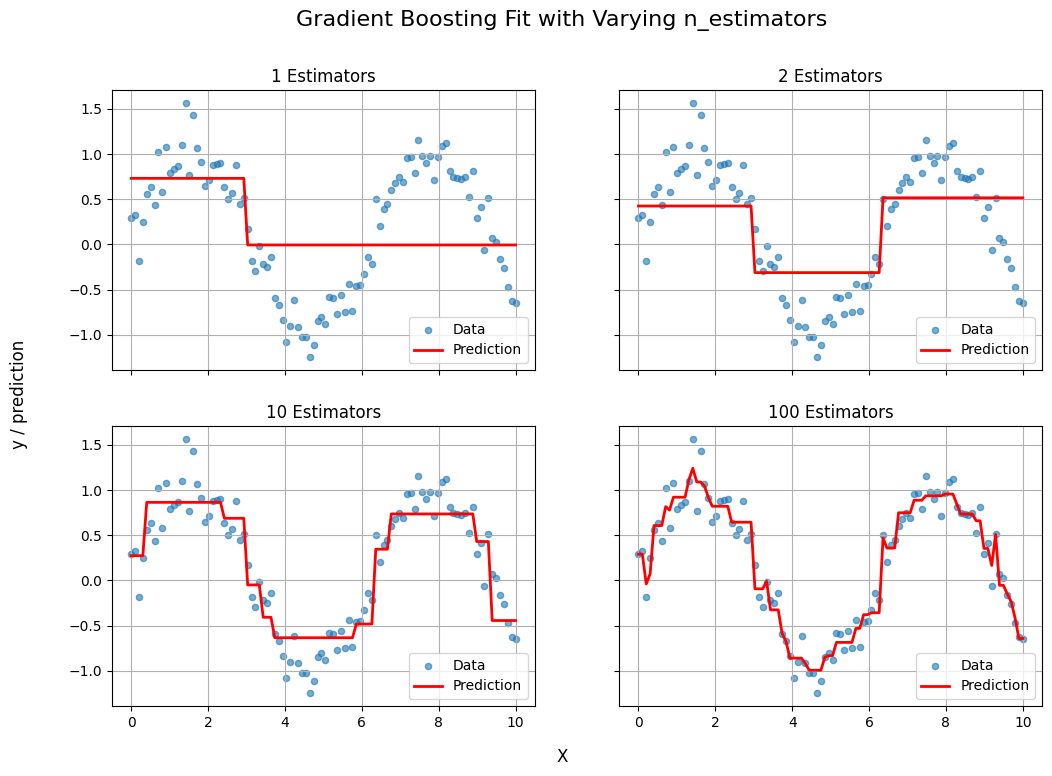

In [298]:
# Generate synthetic regression data
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, size=X.shape[0])

# Plotting the results with varying n_estimators
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
fig.suptitle("Gradient Boosting Fit with Varying n_estimators", fontsize=16)

n_rows = 2
n_cols = 2
n_estimators_list = [1, 2, 10, 100]

for i, (n_estimators, ax) in enumerate(zip(n_estimators_list, axes.flatten())):
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=1.0,
        base_model_cls=DecisionStumpRegressor
    )
    model.fit(X, y)
    y_pred = model(X)

    ax.scatter(X, y, label='Data', s=20, alpha=0.6)
    ax.plot(X, y_pred, color='red', lw=2, label='Prediction')
    ax.set_title(f"{n_estimators} Estimators", fontsize=12)
    ax.grid(True)
    ax.legend(loc='lower right')

# Add common axis labels
fig.text(0.5, 0.04, 'X', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'y / prediction', va='center', rotation='vertical', fontsize=12)
#plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space for suptitle
plt.show()


## 🔌 Test on Household Power Consumption Data

To evaluate the performance of gradient boosting on a **real-world regression task**, we use the [**Individual Household Electric Power Consumption** dataset](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption) from the UCI Repository. This dataset contains **minute-level electricity usage** recorded over several years for a single household. 

For this experiment, we focus on:

- **Global active power** (in kilowatts) as the target variable  
- The following temporal features as input:
  - **Hour of day** ($0 \ldots 23$)  
  - **Day of week** ($0 \ldots 6$, with 0 = Monday)  
  - **Month** ($1 \ldots 12$)

We first aggregate the data into **hourly averages**, then use these time-derived features to predict the power usage. This setup captures **daily**, **weekly**, and **seasonal** patterns in electricity demand.

By comparing a **linear model** with **gradient boosting**, we can evaluate how well each approach captures the inherent **nonlinear structure** in the data. In particular, boosting is able to model interactions between hour, weekday, and month — which a simple linear model cannot do without explicit feature engineering.


### Load and Preprocess Data

In [ ]:
# Load raw CSV without parsing dates
df = pd.read_csv("household_power_consumption.txt", 
                 sep=';', 
                 na_values='?',
                 low_memory=False)

# Create Datetime column FIRST
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'], 
    format='%d/%m/%Y %H:%M:%S', 
    errors='coerce'
)


# Keep only necessary columns
df = df[['Datetime', 'Global_active_power']]

# Convert to numeric
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')


# Set datetime index for resampling
df.set_index('Datetime', inplace=True)

# Resample to hourly mean
df_hourly = df.resample('H').mean().reset_index()
df_hourly.dropna(subset=['Global_active_power'], inplace=True)

# Add features
df_hourly['Hour'] = df_hourly['Datetime'].dt.hour
df_hourly['DayOfWeek'] = df_hourly['Datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df_hourly['Month'] = df_hourly['Datetime'].dt.month

# Final features and target
X = df_hourly[['Hour', 'DayOfWeek', 'Month']].values  # shape (n_samples, 2)
Y = df_hourly['Global_active_power'].values


/var/folders/9v/zb2h9_ys5yz0c88dl39lnxbh0000gn/T/ipykernel_73850/1337651927.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean().reset_index()


### Train Gradient Boosting Model

In [340]:
from courselib.utils.metrics import mean_absolute_error, mean_squared_error

metrics_dict = {
    'MSE': mean_squared_error,
    'MAE': mean_absolute_error
    }


model_gb = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    base_model_cls=DecisionStumpRegressor
)

metrics_history_gb = model_gb.fit(X, Y,
                                  compute_metrics=True,
                                  metrics_dict=metrics_dict)

### Train Linear Regression Model

In [341]:
from courselib.models.linear_models import LinearRegression
from courselib.optimizers import GDOptimizer

w = [0]*X.shape[1]
b = 0

optimizer = GDOptimizer(learning_rate=1e-3)

model_lr = LinearRegression(w, b, optimizer)
metrics_history_lr = model_lr.fit(X,Y,
                                num_epochs=1000,
                                batch_size=len(X),
                                compute_metrics=True,
                                metrics_dict=metrics_dict
                                )

### Performance Comparison

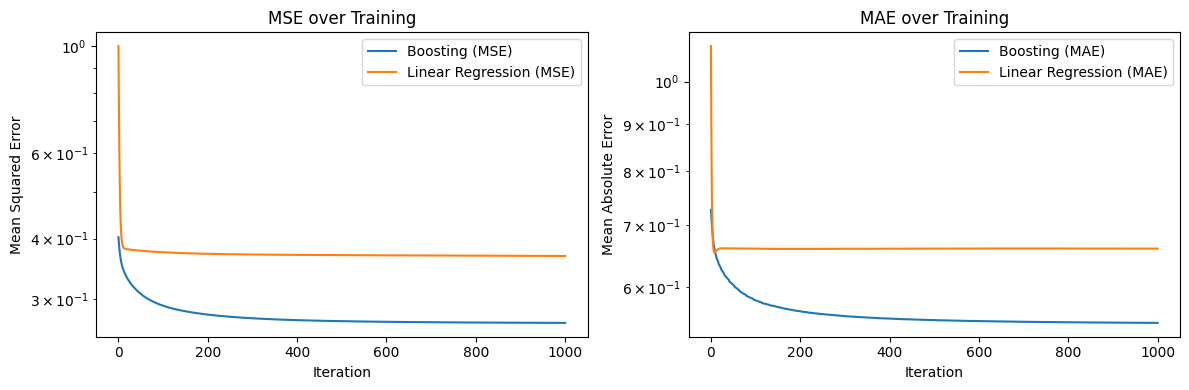

In [342]:
import matplotlib.pyplot as plt

# Boosting
gb_mse = metrics_history_gb['MSE']
gb_mae = metrics_history_gb['MAE']

# Linear
lr_mse = metrics_history_lr['MSE']
lr_mae = metrics_history_lr['MAE']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(gb_mse, label="Boosting (MSE)")
ax[0].plot(lr_mse, label="Linear Regression (MSE)")
ax[0].set_title("MSE over Training")
ax[0].set_ylabel("Mean Squared Error")
ax[0].set_xlabel("Iteration")
ax[0].legend()
ax[0].set_yscale('log')

ax[1].plot(gb_mae, label="Boosting (MAE)")
ax[1].plot(lr_mae, label="Linear Regression (MAE)")
ax[1].set_title("MAE over Training")
ax[1].set_ylabel("Mean Absolute Error")
ax[1].set_xlabel("Iteration")
ax[1].legend()
ax[1].set_yscale('log')

plt.tight_layout()
plt.show()


### 📈 Visualization: Power Usage Predictions Over Several Days

To better understand how the two models behave, we visualize their predictions across a **sequence of consecutive hourly readings** (roughly 4 days of data). This plot shows:

- The **true power consumption** (in kilowatts) as recorded in the dataset  
- Predictions from a **linear regression model**, which can only capture linear trends  
- Predictions from a **gradient boosting model**, which can adapt to non-linear local patterns 


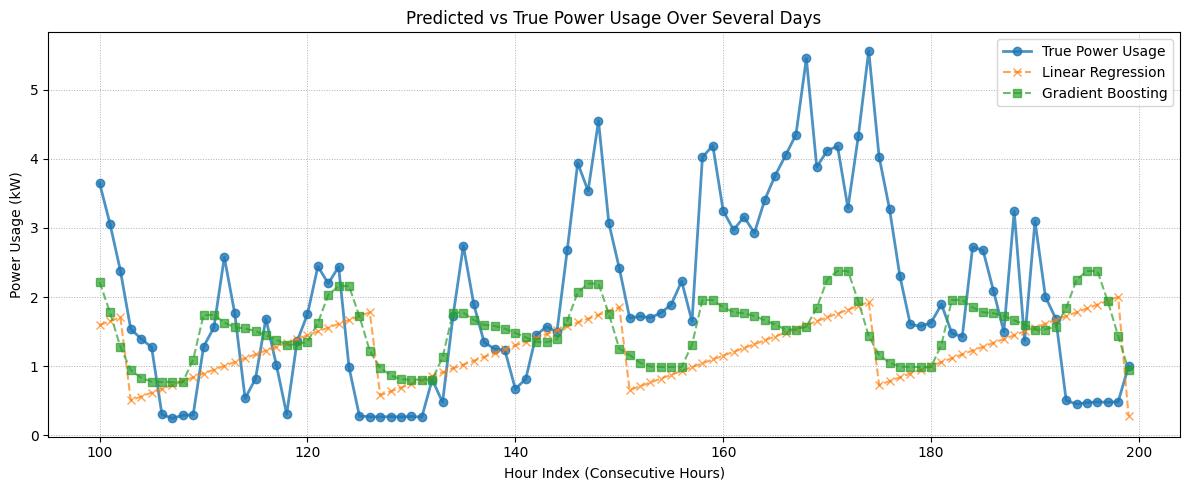

In [344]:
y_pred_lr = model_lr(X)
y_pred_gb = model_gb(X)

indices = np.arange(100,200,1)  # Number of points to plot
# Create an x-axis index for plotting consecutive time steps
time_axis = np.arange(len(Y))[indices]  # or use df_hourly['Datetime'] if available

plt.figure(figsize=(12, 5))

# True values
plt.plot(time_axis, Y[indices], label='True Power Usage', marker='o', linewidth=2, alpha=0.8)

# Linear Regression predictions
plt.plot(time_axis, y_pred_lr[indices], label='Linear Regression', linestyle='--', marker='x', alpha=0.7)

# Gradient Boosting predictions
plt.plot(time_axis, y_pred_gb[indices], label='Gradient Boosting', linestyle='--', marker='s', alpha=0.7)

# Styling
plt.xlabel('Hour Index (Consecutive Hours)')
plt.ylabel('Power Usage (kW)')
plt.title('Predicted vs True Power Usage Over Several Days')
plt.grid(True, linestyle=':', linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()


As expected, gradient boosting learned a non-linear function that predicts the energy consumption change over the hours of a day. In contrast, linear regression only fits a linear function for each day in this setup. 

### 📊 Visualization: Predictions for Different Months

We can also visualize how both models adjust their **hourly predictions** based on additional temporal features — in this case, the **month of the year**.

In the plot below, we show the **average predicted power usage for each hour of the day**, computed separately for several representative months (January, April, July, October). For each month, we average over all days to highlight typical patterns.


/var/folders/9v/zb2h9_ys5yz0c88dl39lnxbh0000gn/T/ipykernel_73850/172328864.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(months))


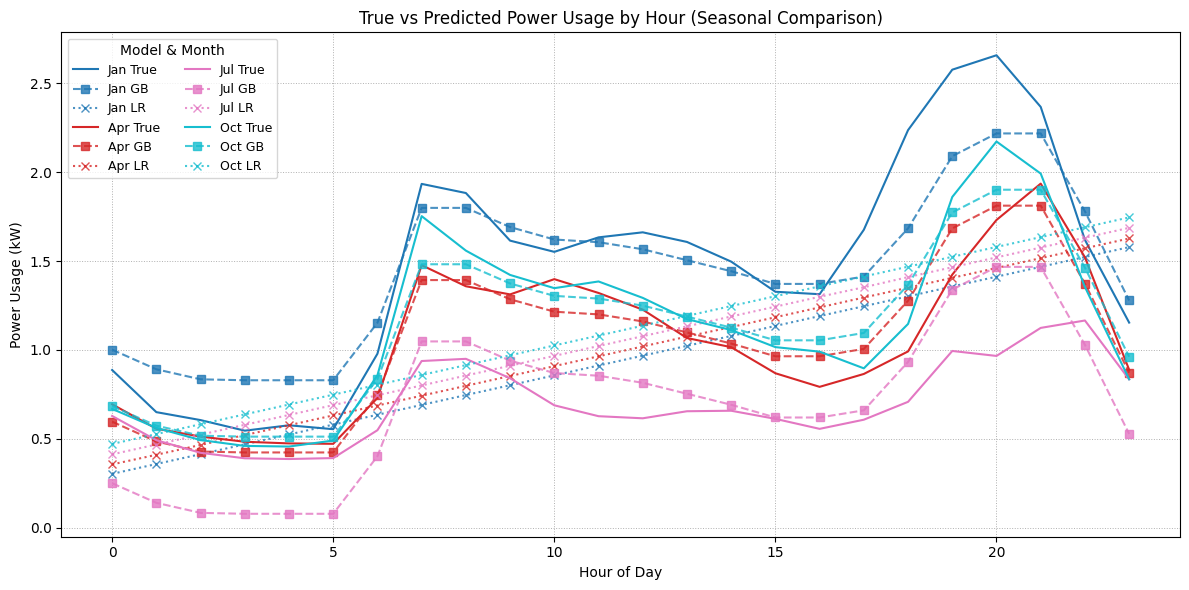

In [351]:
import matplotlib.cm as cm

df_plot = df_hourly.copy()
df_plot['Pred_LR'] = y_pred_lr
df_plot['Pred_GB'] = y_pred_gb

months = [1, 4, 7, 10]
month_labels = {1: "Jan", 4: "Apr", 7: "Jul", 10: "Oct"}

# Create a color map for months
cmap = cm.get_cmap('tab10', len(months))
colors = {month: cmap(i) for i, month in enumerate(months)}

plt.figure(figsize=(12, 6))

for month in months:
    mask = df_hourly['Month'] == month

    avg_true = df_plot[mask].groupby('Hour')['Global_active_power'].mean()
    avg_gb = df_plot[mask].groupby('Hour')['Pred_GB'].mean()
    avg_lr = df_plot[mask].groupby('Hour')['Pred_LR'].mean()

    color = colors[month]
    label = month_labels[month]

    plt.plot(avg_true.index, avg_true.values, label=f'{label} True', color=color, linestyle='-')
    plt.plot(avg_gb.index, avg_gb.values, label=f'{label} GB', color=color, linestyle='--', marker='s', alpha=0.8)
    plt.plot(avg_lr.index, avg_lr.values, label=f'{label} LR', color=color, linestyle=':', marker='x', alpha=0.8)

plt.title("True vs Predicted Power Usage by Hour (Seasonal Comparison)")
plt.xlabel("Hour of Day")
plt.ylabel("Power Usage (kW)")
plt.legend(title="Model & Month", ncol=2, fontsize=9)
plt.grid(True, linestyle=':', linewidth=0.7)
plt.tight_layout()
plt.show()


We can observe the following:
- The **true consumption** changes significantly with the month, showing that energy usage depends on both daily routines and seasons.
- **Gradient Boosting** learns these non-linear seasonal patterns, adjusting the shape of the prediction curve from month to month.
- In contrast, **Linear Regression** produces curves that are **shifted (parallel)** versions of each other. This is because it is **linear in the input features** (including the `Month`) and cannot model interactions unless they are explicitly added as new features.